In [1]:
import pandas as pd
import pickle
import numpy as np
import random
import networkx as nx
from sklearn.model_selection import KFold
import os
from tqdm.auto import tqdm
from collections import defaultdict
import torch
from torch_geometric.data import HeteroData
from torch_geometric.nn import GATConv
from torch.utils.data import Dataset, DataLoader
from torch_geometric.loader import LinkNeighborLoader
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import f1_score, average_precision_score, roc_auc_score
from torch.utils.data import Subset
import time

In [2]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

import torch
torch.autograd.set_detect_anomaly(True)

# ADRD Knowledge Graph Construction

In [3]:
#Load lists of FDA-approved drugs, Neurological diseases, and assicated proteins
with open('input_network/drugs.pkl', 'rb') as f:
    drugs = pickle.load(f)

with open('input_network/diseases.pkl', 'rb') as f:
    diseases = pickle.load(f)

with open('input_network/proteins.pkl', 'rb') as f:
    proteins = pickle.load(f)


#Create mapping from name → integer index for each node type
drug2idx    = {name: i for i, name in enumerate(drugs)}
disease2idx = {name: i for i, name in enumerate(diseases)}
prot2idx    = {name: i for i, name in enumerate(proteins)}

## Initial Node Embeddings Generated using Pretrainde LLM

In [4]:
#Load pre-compute node embeddings
drug_feats_df    = pd.read_csv("input_network/initial_node_features/drug_node.csv", index_col = 0)  # shape (N_drug, 768)

disease_feats_df = pd.read_csv("input_network/initial_node_features/disease_node.csv", index_col = 1)  # shape (N_disease, 768)
disease_feats_df = disease_feats_df.drop(columns = ['Unnamed: 0'])

protein_feats_df    = pd.read_csv("input_network/initial_node_features/protein_node.csv", index_col = 0)  # shape (N_protein, 1280)
protein_feats_df = protein_feats_df.drop_duplicates()

## Initial Node Embedding Imputation

In [5]:
#Impute missing node embeddings expecially for drugs as not all FDA approved drugs have SMILES
num_drugs    = len(drug2idx)
num_diseases = len(disease2idx)
num_prots    = len(prot2idx)

#Initialize feature matrices with zeros
drug_feats    = torch.zeros((num_drugs,    768))
disease_feats = torch.zeros((num_diseases, 768))
protein_feats    = torch.zeros((num_prots,    1280))

#list of nodes with missing intial node embeddings
missing_drugs, missing_diseases, missing_proteins = [], [], []

#Impute missing node embeddings for drugs
for drug, idx in drug2idx.items():
    if drug in drug_feats_df.index:
        drug_feats[idx] = torch.tensor(drug_feats_df.loc[drug].values, dtype = torch.float)
    else:
        missing_drugs.append((drug, idx))

#Impute missing node embeddings for diseases
for disease, idx in disease2idx.items():
    if disease in disease_feats_df.index:
        disease_feats[idx] = torch.tensor(disease_feats_df.loc[disease].values, dtype = torch.float)
    else:
        missing_diseases.append((disease, idx))

#Impute missing node embeddings for proteins
for protein, idx in prot2idx.items():
    if protein in protein_feats_df.index:
        protein_feats[idx] = torch.tensor(protein_feats_df.loc[protein].values, dtype = torch.float)
    else:
        missing_proteins.append((protein, idx))

#Impute missing node embeddings by sampling from the nearest neighbors
def impute_missing(feats, missing_idxs, sample_k):
    all_idxs = [i for i in range(feats.size(0)) if i not in missing_idxs]
    for _ , mi in missing_idxs:
        sampled = random.sample(all_idxs, sample_k)
        feats[mi] = feats[sampled].mean(dim = 0)
    return feats

drug_feats    = impute_missing(drug_feats, missing_drugs, len(drug2idx))
disease_feats = impute_missing(disease_feats, missing_diseases, len(disease2idx))
protein_feats    = impute_missing(protein_feats, missing_proteins, len(prot2idx))


## Load Similarity and Bipartite links

In [6]:
#read and load similarity edges as edge weight tensor
#use same index mapping for source and destination nodes as in the node embeddings
def load_similarity_edges(file_path, src2idx, dst2idx):

    #read similarity edges from csv file
    df = pd.read_csv(file_path)
    df = df.drop(columns = ['Unnamed: 0'])
    #map to indices
    src = [src2idx[x] for x in df.iloc[:, 0]]
    dst = [dst2idx[x] for x in df.iloc[:, 1]]
    #generate edge index tensor
    edge_index = torch.tensor([src + dst, dst + src], dtype = torch.long)  # make undirected as similarity edges are bidirectional
    #generate edge weight tensor
    edge_weight = torch.ones(edge_index.size(1), dtype = torch.float)

    return edge_index, edge_weight

#read and load bipartite edges as edge weight tensor
#edge weight is 1 for all edges as they are binary
def load_bipartite_edges(file_path, src2idx, dst2idx):

    #read bipartite edges from csv file
    df = pd.read_csv(file_path)
    try:
        df = df.drop(columns = ['Unnamed: 0'])
    except KeyError:
        pass
    #map to indices
    src = [src2idx[x] for x in df.iloc[:, 0]]
    dst = [dst2idx[x] for x in df.iloc[:, 1]]
    #generate edge index tensor
    edge_index = torch.tensor([src,dst], dtype = torch.long)  # make undirected as associations are bidirectional
    #generate edge weight tensor
    edge_weight = torch.ones(edge_index.size(1), dtype = torch.float)

    return edge_index, edge_weight

#similarity edges
dr_dr_idx, dr_dr_w = load_similarity_edges("input_network/sim_net/drug_sim_0_5.csv", drug2idx, drug2idx)
di_di_idx, di_di_w = load_similarity_edges("input_network/sim_net/disease_sim_median.csv", disease2idx, disease2idx)
pr_pr_idx, pr_pr_w = load_similarity_edges("input_network/sim_net/protein_sim_500.csv", prot2idx, prot2idx)

#Bipartite edges
dr_di_idx, dr_di_w = load_bipartite_edges("input_network/bipartite_net/drug_disease_2.csv", drug2idx, disease2idx)
di_pr_idx, di_pr_w = load_bipartite_edges("input_network/bipartite_net/disease_protein.csv", disease2idx, prot2idx)
dr_pr_idx, dr_pr_w = load_bipartite_edges("input_network/bipartite_net/drug_protein.csv", drug2idx, prot2idx)

## HeteroData object

In [7]:
#data object
data = HeteroData()

#assign node features
data["drug"].x    = drug_feats
data["disease"].x = disease_feats
data["protein"].x = protein_feats

# drug similarity edges
data["drug", "sim", "drug"].edge_index  = dr_dr_idx
data["drug", "sim", "drug"].edge_weight = dr_dr_w

# disease similarity edges
data["disease", "sim", "disease"].edge_index  = di_di_idx
data["disease", "sim", "disease"].edge_weight = di_di_w

# protein similarity edges
data["protein", "sim", "protein"].edge_index  = pr_pr_idx
data["protein", "sim", "protein"].edge_weight = pr_pr_w


#Drug-disease bipartite edges
data["drug", "interacts", "disease"].edge_index    = dr_di_idx
data["drug", "interacts", "disease"].edge_weight   = dr_di_w

#Disease-protein bipartite edges
data["disease", "assoc", "protein"].edge_index   = di_pr_idx
data["disease", "assoc", "protein"].edge_weight  = di_pr_w

#Drug-protein bipartite edges
data["drug", "binds", "protein"].edge_index    = dr_pr_idx
data["drug", "binds", "protein"].edge_weight   = dr_pr_w


# Negative sampling and Cross-validation

## Positive Edges Degree Distribution Probability

In [8]:
#Build a networkx graph for hop-neighborhood queries
#graph object
G_nx = nx.Graph()

#add nodes
for ntype in data.node_types: #drug, disease, protein
    G_nx.add_nodes_from(
        [(f"{ntype}_{i}", {"type": ntype}) for i in range(data[ntype].num_nodes)]
    )

#add edges
for (src_type, rel, dst_type) in data.edge_types:
    src, dst = data[(src_type, rel, dst_type)].edge_index
    edges = [(f"{src_type}_{u}", f"{dst_type}_{v}") for u, v in zip(src.tolist(), dst.tolist())]
    G_nx.add_edges_from(edges)

#precompute per-node degree distributions
#endpoint_counts maps each edge type to its (P_src, P_dst) tuple.
endpoint_counts = {}
for (u_t, rel, v_t) in data.edge_types:
    src, dst = data[(u_t, rel, v_t)].edge_index

    # count how often each node appears as src or dst in POSITIVE edges
    src_counts = torch.bincount(src, minlength=data[u_t].num_nodes).float()
    dst_counts = torch.bincount(dst, minlength=data[v_t].num_nodes).float()

    # normalize into probability vectors
    P_src = (src_counts / src_counts.sum())
    P_dst = (dst_counts / dst_counts.sum())

    #add a small constant to make sure if nodes are isolated, they still have a small probability
    src_counts += 1e-6
    dst_counts += 1e-6

    #store the result
    endpoint_counts[(u_t, rel, v_t)] = (P_src, P_dst)


## Precompute 3-hop neighbors

In [9]:
# def precompute_hop_neighbors(G_nx, data, k_hop):
#     hop_neighbors = {}

#     #outer bar: one entry per (u_t,rel,v_t)
#     rel_iter = tqdm(
#         data.edge_types,
#         desc="Relations",
#         unit="rel"
#     )

#     for (u_t, rel, v_t) in rel_iter:
#         N_u = data[u_t].num_nodes
#         uv_neighbors = {}

#         #inner bar: N_u nodes per relation
#         node_iter = tqdm(
#             range(N_u),
#             desc=f"{u_t}→{v_t} nodes",
#             unit="u",
#             leave=False
#         )

#         prefix = f"{v_t}_"
#         for u in node_iter:
#             u_node = f"{u_t}_{u}"
#             reachable = nx.single_source_shortest_path_length(
#                 G_nx, u_node, cutoff=k_hop
#             ).keys()

#             # collect only those of type v_t
#             vt_set = {
#                 int(n.split("_", 1)[1])
#                 for n in reachable
#                 if n.startswith(prefix)
#             }
#             uv_neighbors[u] = vt_set

#         hop_neighbors[(u_t, v_t)] = uv_neighbors

#     return hop_neighbors

# #precompute hop neighbors
# hop_neighbors = precompute_hop_neighbors(G_nx, data, k_hop = 3)

# #save precomputed 3-hop neighbors for faster loading
# with open("intermediate_data_save/precomputed_hop_neighbors.pkl", "wb") as f:
#     pickle.dump(hop_neighbors, f)

with open("intermediate_data_save/precomputed_hop_neighbors.pkl", "rb") as f:
    hop_neighbors = pickle.load(f)

## Negative Sampling per Relation-type

In [10]:
#uniform random negative sampling per relation
def sample_neg_uniform(data, pos_sets, u_t, rel, v_t, num_samples):
    #number of source and destination nodes
    N_u, N_v = data[u_t].num_nodes, data[v_t].num_nodes
    #positive edge set
    pos = pos_sets[(u_t, rel, v_t)]
    #negative edge set
    neg = []

    #draw negative samples until we have num_samples
    while len(neg) < num_samples:
        #draw source and destination nodes uniformly
        u = random.randrange(N_u)
        v = random.randrange(N_v)

        #if the edge is not in the positive edge set, add it to the negative edge set
        if (u, v) not in pos:
            neg.append((u, v))

    return torch.tensor(neg).t()

#sample negative edges with k-hop exclusion
def sample_neg_3hop(data, pos_sets, hop_neighbors, u_t, rel, v_t, num_samples):

    #number of source and destination nodes
    N_u, N_v = data[u_t].num_nodes, data[v_t].num_nodes
    #positive edge set
    pos   = pos_sets[(u_t, rel, v_t)]
    #3-hop neighbors
    hop_n = hop_neighbors[(u_t, v_t)]

    neg = []

    #draw negative samples until we have num_samples
    while len(neg) < num_samples:
        #draw source and destination nodes uniformly
        u = random.randrange(N_u)
        v = random.randrange(N_v)

        #if the edge is in the positive edge set, skip
        if (u, v) in pos:
            continue
        #if the destination node is in the 3-hop neighbors of the source node, skip
        if v in hop_n[u]:
            continue
        neg.append((u, v))

    return torch.tensor(neg).t()

#sample negative edges with degree-matched and k-hop exclusion
def sample_neg_prob_deg(data,  #data object
                        pos_sets, #positive edge set
                        hop_neighbors, #3-hop neighbors
                        endpoint_counts, #endpoint counts, P_src and P_dst for source and destination nodes
                        u_t, rel, v_t, #edge type
                        num_samples, #number of negative samples
                        max_attempts): #maximum number of attempts

    #number of source and destination nodes
    N_u, N_v    = data[u_t].num_nodes, data[v_t].num_nodes
    #probability vectors for source and destination nodes
    P_src, P_dst= endpoint_counts[(u_t, rel, v_t)]
    #positive edge set
    pos = pos_sets[(u_t, rel, v_t)]
    #3-hop neighbors
    hop_n = hop_neighbors[(u_t, v_t)]

    neg = []
    for _ in range(num_samples):
        # try degree-matched draws
        for _try in range(max_attempts):
            #draw source node from P_src
            u = np.random.choice(N_u, p = P_src)
            #draw destination node from P_dst
            v = np.random.choice(N_v, p = P_dst)
            #if the edge is in the positive edge set or the destination node is in the k-hop neighbors of the source node, skip
            if (u, v) in pos or v in hop_n[u]:
                continue
            neg.append((u, v))
            break
        #if we have tried max_attempts and still haven't found a valid negative sample, fallback to uniform + hop check
        else:
            # fallback to uniform + hop check
            while True:
                u = random.randrange(N_u)
                v = random.randrange(N_v)

                if (u, v) in pos:
                    continue

                if (u, v) in pos or v in hop_n[u]:
                    continue

                neg.append((u, v))
                break
    return torch.tensor(neg).t()


def sample_negatives(data, #data object
                     pos_sets, #positive edge set
                     hop_neighbors, #3-hop neighbors
                     endpoint_counts, #endpoint counts, P_src and P_dst for source and destination nodes
                     u_t, rel, v_t, #edge type
                     num_samples, #number of negative samples
                     strategy): #sampling strategy

    if strategy == "random":
        return sample_neg_uniform(data, pos_sets, u_t, rel, v_t, num_samples)

    elif strategy == "3-hop":
        return sample_neg_3hop(data, pos_sets, hop_neighbors, u_t, rel, v_t, num_samples)

    elif strategy == "pdf":
        return sample_neg_prob_deg(
            data, pos_sets, hop_neighbors, endpoint_counts,
            u_t, rel, v_t, num_samples, max_attempts = 20)

    else:
        raise ValueError(f"Unknown sampling strategy: {strategy}")

In [11]:
#build positive edge sets
def build_pos_sets(data):
    pos_sets = {}
    for (u_t, rel, v_t) in data.edge_types:
        edge_index = data[(u_t, rel, v_t)].edge_index.t().tolist()
        pos_sets[(u_t, rel, v_t)] = set(tuple(e) for e in edge_index)
    return pos_sets

pos_sets = build_pos_sets(data)

## K-Fold Cross Validation

In [12]:
def k_fold_link_splits(data, #data object
                       pos_sets, #positive edge set
                       hop_neighbors, #3-hop neighbors
                       endpoint_counts, #endpoint counts, P_src and P_dst for source and destination nodes
                       G_nx, #networkx graph
                       u_t, # source node type
                       rel, # relation type
                       v_t, # destination node type
                       k, # number of folds
                       random_state,
                       strategy):  # "random"|"3-hop"|"pdf"

    #positive edge set indices
    pos_idx = data[(u_t, rel, v_t)].edge_index.t().tolist()
    pos_idx = np.array(pos_idx)

    #k-fold cross-validation
    kf = KFold(n_splits = k, shuffle = True, random_state = random_state)

    #iterate over folds
    #here splits means different relation types (u_t, rel, v_t)
    #train_ix and test_ix are indices of the positive edge set
    for train_ix, test_ix in kf.split(pos_idx):
        #train and test positive edge sets
        train_pos = torch.tensor(pos_idx[train_ix]).t()
        test_pos  = torch.tensor(pos_idx[test_ix]).t()

        M_train = train_pos.size(1)
        M_test  = test_pos.size(1)

        #select negative edges for train and test sets
        train_neg = sample_negatives(
            data, pos_sets, hop_neighbors, endpoint_counts,
            u_t, rel, v_t, M_train,
            strategy = strategy
        )
        test_neg = sample_negatives(
            data, pos_sets, hop_neighbors, endpoint_counts,
            u_t, rel, v_t, M_test,
            strategy = strategy
        )

        #yield the train and test sets for the current fold
        yield {
            'train_pos': train_pos,
            'train_neg': train_neg,
            'test_pos' : test_pos,
            'test_neg' : test_neg,
        }

In [13]:
# folds_by_relation = {}
# relations = list(data.edge_types)

# #outer bar: iterate through each (u_t,rel,v_t)
# for u_t, rel, v_t in tqdm(relations, desc = "Relations", unit = "rel"):
#     key = f"{u_t}-{rel}-{v_t}"
    
#     # iner bar: wrap the generator from k_fold_link_splits
#     folds = list(
#         tqdm(
#             k_fold_link_splits(
#                 data, #data object
#                 pos_sets, #positive edge set
#                 hop_neighbors, #3-hop neighbors
#                 endpoint_counts, #endpoint counts, P_src and P_dst for source and destination nodes
#                 G_nx, #networkx graph
#                 u_t, rel, v_t, #edge type
#                 k = 5, #number of folds
#                 random_state = 40, #random state
#                 strategy = "3-hop"    #  "random" | "3-hop" | "pdf"
#             ),
#             total   = 5, #number of folds
#             desc = f"Folds for {key}", #description
#             unit = "fold", #unit
#             leave = False #leave
#         )
#     )
    
#     folds_by_relation[key] = folds

# #save precomputed 3-hop neighbors for faster loading
# with open("intermediate_data_save/folds_by_relation_3_hop.pkl", "wb") as f:
#     pickle.dump(folds_by_relation, f)

with open("intermediate_data_save/folds_by_relation_3_hop.pkl", "rb") as f:
    folds_by_relation = pickle.load(f)

# Data Loader

In [17]:
def build_train_graph(full_data, folds_by_relation, fold_idx):

    train_data = HeteroData()
    # 1) Copy node features
    for ntype in full_data.node_types:
        train_data[ntype].x = full_data[ntype].x

    # 2) For each relation, remove all test edges (positive and negative)
    for (u_t, rel, v_t) in full_data.edge_types:
        key = f"{u_t}-{rel}-{v_t}"
        e_full = full_data[u_t, rel, v_t].edge_index

        # Gather test positive and negative edges for this relation/fold
        test_pos = folds_by_relation[key][fold_idx]['test_pos']  # [2, E_test_pos]
        test_neg = folds_by_relation[key][fold_idx].get('test_neg', torch.empty((2,0), dtype=e_full.dtype, device=e_full.device))  # [2, E_test_neg] or empty

        # Combine test positive and negative edges into a set for exclusion
        test_edges = torch.cat([test_pos, test_neg], dim=1) if test_neg.numel() > 0 else test_pos
        test_set = {tuple(x) for x in test_edges.t().tolist()}

        # Build a boolean mask: keep only edges NOT in test_set
        mask = [(tuple(e_full[:, i].tolist()) not in test_set)
                for i in range(e_full.size(1))]
        mask = torch.tensor(mask, dtype=torch.bool, device=e_full.device)

        # Assign the pruned edges
        train_data[u_t, rel, v_t].edge_index = e_full[:, mask]

    return train_data


For attention Visusalization

In [18]:
class ADRD_LinkPredictor(nn.Module):
    def __init__(self,
                 in_dims,
                 hidden_dim,
                 gat_heads,
                 fusion_heads,
                 dropout,
                 beta):
        super().__init__()
        self.beta = beta
        # A) Linear transforms
        self.type_linears = nn.ModuleDict({
            n: nn.Linear(in_dims[n], hidden_dim) for n in in_dims
        })
        self.shared_lin = nn.Linear(hidden_dim, hidden_dim)

        # All 6 relation keys
        self.rel_keys = [
            'drug-sim-drug', 'disease-sim-disease', 'protein-sim-protein',
            'drug-interacts-disease','disease-assoc-protein','drug-binds-protein'
        ]

        # B) 2-layer GATs
        self.gat1 = nn.ModuleDict({
            k: GATConv(hidden_dim, hidden_dim//gat_heads, heads=gat_heads, dropout = dropout,  concat=True)
            for k in self.rel_keys
        })
        self.gat2 = nn.ModuleDict({
            k: GATConv(hidden_dim, hidden_dim//gat_heads, heads=gat_heads, dropout = dropout, concat=True)
            for k in self.rel_keys
        })

        # — attention storage for both GAT layers —
        self.attn_weights_gat1 = {k: None for k in self.rel_keys}
        self.attn_weights_gat2 = {k: None for k in self.rel_keys}

        # C) Fusion self-attention (3→1)
        self.fusion_attn = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=fusion_heads,
            batch_first=False,
            dropout=dropout
        )

        self.attn_weights_fusion = {}

        # D) Shared MLP
        self.link_mlp = nn.Sequential(
            nn.Linear(2*hidden_dim, hidden_dim),
            nn.ReLU(),  # no inplace
            nn.Dropout(p=dropout),
            nn.Linear(hidden_dim, 1)
        )
    
    

    def compute_full_graph_embeddings(self, data):
        self.debug_contrib = { 'drug': [], 'disease': [], 'protein': [] }
        # A) Raw feature → shared space
        x = {}
        for ntype in data.node_types:
            h = F.relu(self.type_linears[ntype](data[ntype].x))
            x[ntype] = F.relu(self.shared_lin(h))

        # Prepare container for each node‐type’s list of [N_ntype×H]
        embs = {ntype: [] for ntype in data.node_types}

        # B) Run each of the 6 GATs, capturing layer-1 & layer-2 attention
        bip_keys = {
            'drug-interacts-disease': ('drug','disease'),
            'disease-assoc-protein':   ('disease','protein'),
            'drug-binds-protein':      ('drug','protein'),
        }

        

        for key in self.rel_keys:
            # u_t, rel, v_t = key.split('-')
            c1, c2 = self.gat1[key], self.gat2[key]
            # ei = data[u_t, rel, v_t].edge_index.to(x[u_t].device)

            u_t, rel, v_t = key.split('-')
            ei = data[u_t, rel, v_t].edge_index.to(x[u_t].device)

            # — Skip any relation with zero edges (like drug–disease during training) —
            if ei.numel() == 0:
                continue

            if key in bip_keys:
                # bipartite → undirected on concatenated features
                h_u, h_v = x[u_t], x[v_t]
                N_u = h_u.size(0)
                h_comb = torch.cat([h_u, h_v], dim=0)

                # build bidirectional edges
                ei_fwd = ei.clone(); ei_fwd[1] += N_u
                ei_rev = ei.flip(0).clone(); ei_rev[0] += N_u
                ei_bid = torch.cat([ei_fwd, ei_rev], dim=1).to(h_comb.device)

                # layer-1 with attention
                h1, (_, attn1) = c1(h_comb, ei_bid, return_attention_weights=True)
                self.attn_weights_gat1[key] = attn1.mean(dim=1).detach()
                h1 = F.elu(h1)

                # layer-2 with attention
                h2, (_, attn2) = c2(h1, ei_bid, return_attention_weights=True)
                self.attn_weights_gat2[key] = attn2.mean(dim=1).detach()
                

                # split back out
                embs[u_t].append(h2[:N_u])
                embs[v_t].append(h2[N_u:])

            else:
                # homogeneous similarity
                h1, (_, attn1) = c1(x[u_t], ei, return_attention_weights=True)
                self.attn_weights_gat1[key] = attn1.mean(dim=1).detach()
                h1 = F.elu(h1)

                h2, (_, attn2) = c2(h1, ei, return_attention_weights=True)
                self.attn_weights_gat2[key] = attn2.mean(dim=1).detach()

                embs[u_t].append(h2)


        # C) Fuse each node‐type’s 3 embeddings → 1 (unchanged)
        H_fused = {}
        for ntype, lst in embs.items():
            stacked = torch.stack(lst, dim=0)
            fused, _ = self.fusion_attn(stacked, stacked, stacked)
            fused, fusion_attn = self.fusion_attn(stacked, stacked, stacked,
                                                  need_weights=True,
                                                  average_attn_weights=False
                                                  )
            self.attn_weights_fusion[ntype] = fusion_attn.detach()  # [n_heads, 3, 3]
            H_fused[ntype] = fused.mean(dim=0)

        #Combine into one giant embedding + record offsets
        H_drug = H_fused['drug']
        H_dis  = H_fused['disease']
        H_prot = H_fused['protein']

        offsets = {
            'drug':    0,
            'disease': H_drug.size(0),
            'protein': H_drug.size(0) + H_dis.size(0)
        }

        H_all = torch.cat([H_drug, H_dis, H_prot], dim=0)
        return H_all, offsets
    

    # def forward(self, H_fused, u_types, v_types, u_idx, v_idx):
    #     # D) gather & MLP
    #     hu = torch.stack([H_fused[ut][i] for ut,i in zip(u_types, u_idx)], dim=0)
    #     hv = torch.stack([H_fused[vt][j] for vt,j in zip(v_types, v_idx)], dim=0)
    #     x  = torch.cat([hu, hv], dim=-1)
    #     return self.link_mlp(x).squeeze(-1)

    def forward(self, H_all, offsets, u_types, v_types, u_idx, v_idx):
        # Build per‐sample offsets
        off_u = torch.tensor([offsets[ut] for ut in u_types], dtype=torch.long, device=H_all.device)
        off_v = torch.tensor([offsets[vt] for vt in v_types], dtype=torch.long, device=H_all.device)

        # Compute global indices
        u_glob = u_idx + off_u
        v_glob = v_idx + off_v

        # Gather embeddings in one go
        hu = H_all[u_glob]   # [B, H]
        hv = H_all[v_glob]   # [B, H]

        x  = torch.cat([hu, hv], dim=-1)  # [B, 2H]
        return self.link_mlp(x).squeeze(-1)


    def compute_loss(self, logits, labels, rel_types):
        # E) weighted BCE
        sim = {'drug-sim-drug','disease-sim-disease','protein-sim-protein'}
        is_sim = torch.tensor([rt in sim for rt in rel_types], device=logits.device)
        is_bip = ~is_sim
        fn = F.binary_cross_entropy_with_logits
        l_sim = fn(logits[is_sim], labels[is_sim]) if is_sim.any() else 0.0
        l_bip = fn(logits[is_bip], labels[is_bip]) if is_bip.any() else 0.0
        return self.beta * l_bip + (1-self.beta) * l_sim

# ──────────────────────────────────────────────────────────────────────────────
# 4) Edge‐batch Dataset & DataLoader
# ──────────────────────────────────────────────────────────────────────────────
class FullGraphLinkDataset(Dataset):
    def __init__(self, folds, fold_idx, split = "train"):
        self.entries = []
        self.debug_contrib = { 'drug': [], 'disease': [], 'protein': [] }

        for rel_key, fl in folds.items():
            pos = fl[fold_idx][f"{split}_pos"].t().tolist()
            neg = fl[fold_idx][f"{split}_neg"].t().tolist()
            u_t, _, v_t = rel_key.split('-')
            for u,v in pos: self.entries.append((rel_key, u_t, v_t, u, v, 1.0))
            for u,v in neg: self.entries.append((rel_key, u_t, v_t, u, v, 0.0))

    def __len__(self): return len(self.entries)
    def __getitem__(self, i):
        rel_key, u_t, v_t, u, v, lbl = self.entries[i]
        return rel_key, u_t, v_t, torch.tensor(u), torch.tensor(v), torch.tensor(lbl)

In [19]:
# class ADRD_LinkPredictor(nn.Module):
#     def __init__(self,
#                  in_dims,
#                  hidden_dim,
#                  gat_heads,
#                  fusion_heads,
#                  dropout,
#                  beta):
#         super().__init__()
#         self.beta = beta
#         # A) Linear transforms
#         self.type_linears = nn.ModuleDict({
#             n: nn.Linear(in_dims[n], hidden_dim) for n in in_dims
#         })
#         self.shared_lin = nn.Linear(hidden_dim, hidden_dim)

#         # All 6 relation keys
#         self.rel_keys = [
#             'drug-sim-drug', 'disease-sim-disease', 'protein-sim-protein',
#             'drug-interacts-disease','disease-assoc-protein','drug-binds-protein'
#         ]

#         # B) 2-layer GATs
#         self.gat1 = nn.ModuleDict({
#             k: GATConv(hidden_dim, hidden_dim//gat_heads, heads=gat_heads, dropout = dropout,  concat=True)
#             for k in self.rel_keys
#         })
#         self.gat2 = nn.ModuleDict({
#             k: GATConv(hidden_dim, hidden_dim, heads=gat_heads, dropout = dropout, concat=False)
#             for k in self.rel_keys
#         })

#         # C) Fusion self-attention (3→1)
#         self.fusion_attn = nn.MultiheadAttention(
#             embed_dim=hidden_dim,
#             num_heads=fusion_heads,
#             batch_first=False,
#             dropout=dropout
#         )

#         # D) Shared MLP
#         self.link_mlp = nn.Sequential(
#             nn.Linear(2*hidden_dim, hidden_dim),
#             nn.ReLU(),  # no inplace
#             nn.Dropout(p=dropout),
#             nn.Linear(hidden_dim, 1)
#         )

#     def compute_full_graph_embeddings(self, data):

#         # A) Raw feature → shared space
#         x = {}
#         for ntype in data.node_types:
#             h = F.relu(self.type_linears[ntype](data[ntype].x))
#             x[ntype] = F.relu(self.shared_lin(h))

#         # Prepare container for each node‐type’s list of [N_ntype×H] embeddings
#         embs = {ntype: [] for ntype in data.node_types}

#         # B) Run each of the 6 GATs
#         for key in self.rel_keys:
#             u_t, rel, v_t = key.split('-')
#             c1, c2 = self.gat1[key], self.gat2[key]
#             ei = data[u_t, rel, v_t].edge_index.to(x[u_t].device)

#             if u_t == v_t:
#                 # similarity (homogeneous)
#                 h1 = F.elu(c1(x[u_t], ei))
#                 h2 = c2(h1, ei)                  # [N_u, H]
#                 embs[u_t].append(h2)

#             else:
#                 # bipartite: ensure correct (src,dst) orientation
#                 N_u = x[u_t].size(0)
#                 N_v = x[v_t].size(0)
#                 max_src, max_dst = ei[0].max().item(), ei[1].max().item()
#                 if max_src >= N_u or max_dst >= N_v:
#                     # flip rows if they got swapped at load time
#                     ei = ei.flip(0).contiguous()

#                 # build the undirected view exactly once
#                 h_u, h_v = x[u_t], x[v_t]
#                 h_comb   = torch.cat([h_u, h_v], dim=0)  # [N_u+N_v, H]

#                 # forward edges map dst→[N_u..]
#                 ei_fwd = ei.clone()
#                 ei_fwd[1] += N_u

#                 # reverse edges map src→[N_u..]
#                 ei_rev = ei.flip(0).clone()
#                 ei_rev[0] += N_u

#                 ei_bid = torch.cat([ei_fwd, ei_rev], dim=1).to(h_comb.device)

#                 h1 = F.elu(c1(h_comb, ei_bid))
#                 h2 = c2(h1,    ei_bid)               # [N_u+N_v, H]

#                 # split back out
#                 embs[u_t].append(h2[:N_u])           # [N_u, H]
#                 embs[v_t].append(h2[N_u:])           # [N_v, H]

#         # C) Fuse each node‐type’s 3 embeddings → 1
#         H_fused = {}
#         for ntype, lst in embs.items():
#             # lst is 3 × [N_ntype, H]
#             stacked = torch.stack(lst, dim=0)        # [3, N_ntype, H]
#             fused, _ = self.fusion_attn(stacked, stacked, stacked)
#             H_fused[ntype] = fused.mean(dim=0)       # [N_ntype, H]

#         # —— NEW PART —— Combine into one giant embedding + record offsets
#         H_drug = H_fused['drug']                    # [N_drug, H]
#         H_dis  = H_fused['disease']                 # [N_disease, H]
#         H_prot = H_fused['protein']                 # [N_protein, H]

#         offsets = {
#             'drug':    0,
#             'disease': H_drug.size(0),
#             'protein': H_drug.size(0) + H_dis.size(0)
#         }

#         H_all = torch.cat([H_drug, H_dis, H_prot], dim=0)  # [N_drug+N_disease+N_protein, H]

#         return H_all, offsets


#     # def forward(self, H_fused, u_types, v_types, u_idx, v_idx):
#     #     # D) gather & MLP
#     #     hu = torch.stack([H_fused[ut][i] for ut,i in zip(u_types, u_idx)], dim=0)
#     #     hv = torch.stack([H_fused[vt][j] for vt,j in zip(v_types, v_idx)], dim=0)
#     #     x  = torch.cat([hu, hv], dim=-1)
#     #     return self.link_mlp(x).squeeze(-1)

#     def forward(self, H_all, offsets, u_types, v_types, u_idx, v_idx):
#         # Build per‐sample offsets
#         off_u = torch.tensor([offsets[ut] for ut in u_types], dtype=torch.long, device=H_all.device)
#         off_v = torch.tensor([offsets[vt] for vt in v_types], dtype=torch.long, device=H_all.device)

#         # Compute global indices
#         u_glob = u_idx + off_u
#         v_glob = v_idx + off_v

#         # Gather embeddings in one go
#         hu = H_all[u_glob]   # [B, H]
#         hv = H_all[v_glob]   # [B, H]

#         x  = torch.cat([hu, hv], dim=-1)  # [B, 2H]
#         return self.link_mlp(x).squeeze(-1)


#     def compute_loss(self, logits, labels, rel_types):
#         # E) weighted BCE
#         sim = {'drug-sim-drug','disease-sim-disease','protein-sim-protein'}
#         is_sim = torch.tensor([rt in sim for rt in rel_types], device=logits.device)
#         is_bip = ~is_sim
#         fn = F.binary_cross_entropy_with_logits
#         l_sim = fn(logits[is_sim], labels[is_sim]) if is_sim.any() else 0.0
#         l_bip = fn(logits[is_bip], labels[is_bip]) if is_bip.any() else 0.0

#         return self.beta * l_bip + (1-self.beta) * l_sim

# # ──────────────────────────────────────────────────────────────────────────────
# # 4) Edge‐batch Dataset & DataLoader
# # ──────────────────────────────────────────────────────────────────────────────
# class FullGraphLinkDataset(Dataset):
#     def __init__(self, folds, fold_idx, split = "train"):
#         self.entries = []
#         for rel_key, fl in folds.items():
#             pos = fl[fold_idx][f"{split}_pos"].t().tolist()
#             neg = fl[fold_idx][f"{split}_neg"].t().tolist()
#             u_t, _, v_t = rel_key.split('-')
#             for u,v in pos: self.entries.append((rel_key, u_t, v_t, u, v, 1.0))
#             for u,v in neg: self.entries.append((rel_key, u_t, v_t, u, v, 0.0))

#     def __len__(self): return len(self.entries)
#     def __getitem__(self, i):
#         rel_key, u_t, v_t, u, v, lbl = self.entries[i]
#         return rel_key, u_t, v_t, torch.tensor(u), torch.tensor(v), torch.tensor(lbl)

# Model Train

In [20]:
def compute_grouped_metrics(y_true_dict, y_prob_dict, bipartite_keys, similarity_keys):
    rel_metrics = {}

    # Compute per-relation metrics
    for rel_key in y_true_dict.keys():
        y_true_rel = torch.cat(y_true_dict[rel_key]).numpy()
        y_prob_rel = torch.cat(y_prob_dict[rel_key]).numpy()
        y_pred_rel = (y_prob_rel >= 0.5).astype(int)

        f1   = f1_score(y_true_rel, y_pred_rel)
        auc  = roc_auc_score(y_true_rel, y_prob_rel)
        aupr = average_precision_score(y_true_rel, y_prob_rel)
        rel_metrics[rel_key] = (f1, auc, aupr)

    # Separate bipartite vs similarity
    bip_metrics = {k: rel_metrics[k] for k in rel_metrics if k in bipartite_keys}
    sim_metrics = {k: rel_metrics[k] for k in rel_metrics if k in similarity_keys}

    # Average similarity metrics
    if sim_metrics:
        sim_f1   = sum(m[0] for m in sim_metrics.values()) / len(sim_metrics)
        sim_auc  = sum(m[1] for m in sim_metrics.values()) / len(sim_metrics)
        sim_aupr = sum(m[2] for m in sim_metrics.values()) / len(sim_metrics)
    else:
        sim_f1, sim_auc, sim_aupr = None, None, None

    return rel_metrics, bip_metrics, (sim_f1, sim_auc, sim_aupr)


In [21]:
# ──────────────────────────────────────────────────────────────────────────────
# Model initialization
# ──────────────────────────────────────────────────────────────────────────────
device = torch.device("cuda:0" if torch.cuda.device_count() > 1 else ("cuda" if torch.cuda.is_available() else "cpu"))
# device = torch.device("cpu")

data   = data.to(device)

model = ADRD_LinkPredictor(
    in_dims      = {'drug':768, 'disease':768, 'protein':1280},
    hidden_dim   = 1024,
    gat_heads    = 8,
    fusion_heads = 8,
    beta         = 0.75,
    dropout      = 0.35
).to(device)

opt = torch.optim.Adam(model.parameters(), lr = 0.0001, weight_decay = 1e-6)

train_ds = FullGraphLinkDataset(folds_by_relation, 0, "train")
test_ds  = FullGraphLinkDataset(folds_by_relation, 0, "test")

train_ld = DataLoader(train_ds, batch_size = 1024, shuffle = True)
test_ld  = DataLoader(test_ds,  batch_size = 1024, shuffle = False)

In [22]:
from collections import Counter

# Count number of edges per relation
rel_counts = Counter(e[0] for e in train_ld.dataset.entries)
for rel, count in rel_counts.items():
    print(f"{rel}: {count}")

drug-sim-drug: 242252
disease-sim-disease: 588246
protein-sim-protein: 238578
drug-interacts-disease: 18166
disease-assoc-protein: 5444
drug-binds-protein: 18908


In [ ]:
# --- helper: normalize relation key ---
def normalize_rel_key(rel_key):
    # Handle tuple relation keys
    if isinstance(rel_key, tuple):
        return "-".join(rel_key)
    # Handle strings with possible suffixes
    if isinstance(rel_key, str):
        if "#" in rel_key:
            return rel_key.split("#")[0]
        return rel_key
    return str(rel_key)

# --- define relation groups ---
bipartite_keys = {
    "drug-interacts-disease",
    "disease-assoc-protein",
    "drug-binds-protein"
}
similarity_keys = {
    "drug-sim-drug",
    "disease-sim-disease",
    "protein-sim-protein"
}


# Prepare final results container
fold_results = {}

# Number of folds
fold_idx = 0

number_of_runs = 10

for run in range(number_of_runs):
    print(f"\n============================")
    print(f"  Starting Fold {run}")
    print(f"============================")

    # Re-init model + optimizer for each fold!
    model = ADRD_LinkPredictor(
        in_dims      = {'drug':768, 'disease':768, 'protein':1280},
        hidden_dim   = 1024,
        gat_heads    = 8,
        fusion_heads = 8,
        beta         = 0.75,
        dropout      = 0.35).to(device)
    
    opt = torch.optim.Adam(model.parameters(), lr = 0.0001, weight_decay = 1e-6)

    # Storage for this fold
    train_losses, val_losses = [], []
    train_f1s, train_aucs, train_auprs = [], [], []
    val_f1s, val_aucs, val_auprs = [], [], []

    train_graph = build_train_graph(data, folds_by_relation, fold_idx).to(device)

    for epoch in range(1, 90):

        # ====== TRAIN PHASE ======
        model.train()
        H_fused, offsets = model.compute_full_graph_embeddings(train_graph)

        total_graph_loss = 0.0
        total_samples    = 0

        train_probs_dict  = defaultdict(list)
        train_labels_dict = defaultdict(list)
        opt.zero_grad()

        for rel_key_batch, u_t, v_t, u_idx, v_idx, lbl in train_ld:
            u_idx, v_idx, lbl = u_idx.to(device), v_idx.to(device), lbl.to(device)
            logits = model(H_fused, offsets, u_t, v_t, u_idx, v_idx)
            probs  = torch.sigmoid(logits).detach().cpu()

            # unpack batch one edge at a time
            for rk, p, l in zip(rel_key_batch, probs, lbl.detach().cpu()):
                norm_key = normalize_rel_key(rk)
                train_probs_dict[norm_key].append(p.unsqueeze(0))
                train_labels_dict[norm_key].append(l.unsqueeze(0))

            norm_rel_keys = [normalize_rel_key(rk) for rk in rel_key_batch]
            loss = model.compute_loss(logits, lbl, norm_rel_keys)
            total_graph_loss += loss * lbl.size(0)
            total_samples    += lbl.size(0)

        avg_loss = total_graph_loss / total_samples
        avg_loss.backward()
        opt.step()

        # Compute train metrics per relation
        rel_metrics, bip_metrics, sim_avg_metrics = compute_grouped_metrics(
            train_labels_dict, train_probs_dict, bipartite_keys, similarity_keys
        )

        print(f"\nFold {fold_idx} | Epoch {epoch:02d} - TRAIN:")
        for k, (f1, auc, aupr) in bip_metrics.items():
            print(f"  {k:<45} | F1={f1:.4f} AUC={auc:.4f} AUP={aupr:.4f}")
        if sim_avg_metrics[0] is not None:
            print(f"  [Similarity Avg]        | F1={sim_avg_metrics[0]:.4f} "
                  f"AUC={sim_avg_metrics[1]:.4f} AUP={sim_avg_metrics[2]:.4f}\n")

        # if "drug-interacts-disease" in bip_metrics:
        #     train_f1s.append(bip_metrics['drug-interacts-disease'][0])
        #     train_aucs.append(bip_metrics['drug-interacts-disease'][1])
        #     train_auprs.append(bip_metrics['drug-interacts-disease'][2])
        # else:
        #     train_f1s.append(0.0)
        #     train_aucs.append(0.0)
        #     train_auprs.append(0.0)
        train_losses.append(avg_loss.item())

        # ====== VALIDATION PHASE ======
        model.eval()
        total_val_loss = 0.0
        val_samples    = 0
        val_probs_dict  = defaultdict(list)
        val_labels_dict = defaultdict(list)

        with torch.no_grad():
            for rel_key_batch, u_t, v_t, u_idx, v_idx, lbl in test_ld:
                u_idx, v_idx, lbl = u_idx.to(device), v_idx.to(device), lbl.to(device)
                logits = model(H_fused, offsets, u_t, v_t, u_idx, v_idx)
                probs  = torch.sigmoid(logits).cpu()

                for rk, p, l in zip(rel_key_batch, probs, lbl.cpu()):
                    norm_key = normalize_rel_key(rk)
                    val_probs_dict[norm_key].append(p.unsqueeze(0))
                    val_labels_dict[norm_key].append(l.unsqueeze(0))

                norm_rel_keys = [normalize_rel_key(rk) for rk in rel_key_batch]
                loss = model.compute_loss(logits, lbl, norm_rel_keys)
                total_val_loss += loss * lbl.size(0)
                val_samples    += lbl.size(0)

        avg_val_loss = total_val_loss / val_samples

        val_rel_metrics, val_bip_metrics, val_sim_avg = compute_grouped_metrics(
            val_labels_dict, val_probs_dict, bipartite_keys, similarity_keys
        )

        print(f"Fold {fold_idx} | Epoch {epoch:02d} - VALIDATION:")
        for k, (f1, auc, aupr) in val_bip_metrics.items():
            print(f"  {k:<45} | F1={f1:.4f} AUC={auc:.4f} AUP={aupr:.4f}")
        if val_sim_avg[0] is not None:
            print(f"  [Similarity Avg]        | F1={val_sim_avg[0]:.4f} "
                  f"AUC={val_sim_avg[1]:.4f} AUP={val_sim_avg[2]:.4f}\n")
        print(f"  Loss -> Train:{avg_loss:.4f}  Val:{avg_val_loss:.4f}\n")

        val_losses.append(avg_val_loss.item())


    # Rebuild graph for final fold
    final_graph = build_train_graph(data, folds_by_relation, fold_idx).to(device)

    # Compute embeddings for final fold
    model.eval()
    with torch.no_grad():
        H_fused, _ = model.compute_full_graph_embeddings(final_graph)

    # Save the trained model (PyTorch weights)
    torch.save(model.state_dict(), f"p_significance_cal/model_run_5_{run}.pth")
    print(f"Saved model weights")

    #Save the final node embeddings as tensor
    torch.save(H_fused, f"p_significance_cal/node_embeddings_run_5_{run}.pt")
    print(f"Saved node embeddings")


  Starting Fold 0

Fold 0 | Epoch 01 - TRAIN:
  drug-interacts-disease                        | F1=0.0000 AUC=0.5272 AUP=0.4838
  disease-assoc-protein                         | F1=0.0000 AUC=0.5146 AUP=0.4885
  drug-binds-protein                            | F1=0.0000 AUC=0.5102 AUP=0.4899
  [Similarity Avg]        | F1=0.0000 AUC=0.4949 AUP=0.4800

Fold 0 | Epoch 01 - VALIDATION:
  drug-interacts-disease                        | F1=0.0000 AUC=0.8292 AUP=0.7725
  disease-assoc-protein                         | F1=0.0000 AUC=0.5868 AUP=0.5275
  drug-binds-protein                            | F1=0.0000 AUC=0.6476 AUP=0.6037
  [Similarity Avg]        | F1=0.0000 AUC=0.6274 AUP=0.5688

  Loss -> Train:0.6932  Val:0.1870


Fold 0 | Epoch 02 - TRAIN:
  drug-interacts-disease                        | F1=0.7506 AUC=0.8628 AUP=0.8345
  drug-binds-protein                            | F1=0.6406 AUC=0.6647 AUP=0.6492
  disease-assoc-protein                         | F1=0.0000 AUC=0.6463 AUP=0.59

In [3]:
# with open("ADRD_dataset_fold_results.pkl", "wb") as f:
#     pickle.dump(fold_results, f)

with open("fold_results.pkl", "rb") as f:
    fold_results = pickle.load(f)

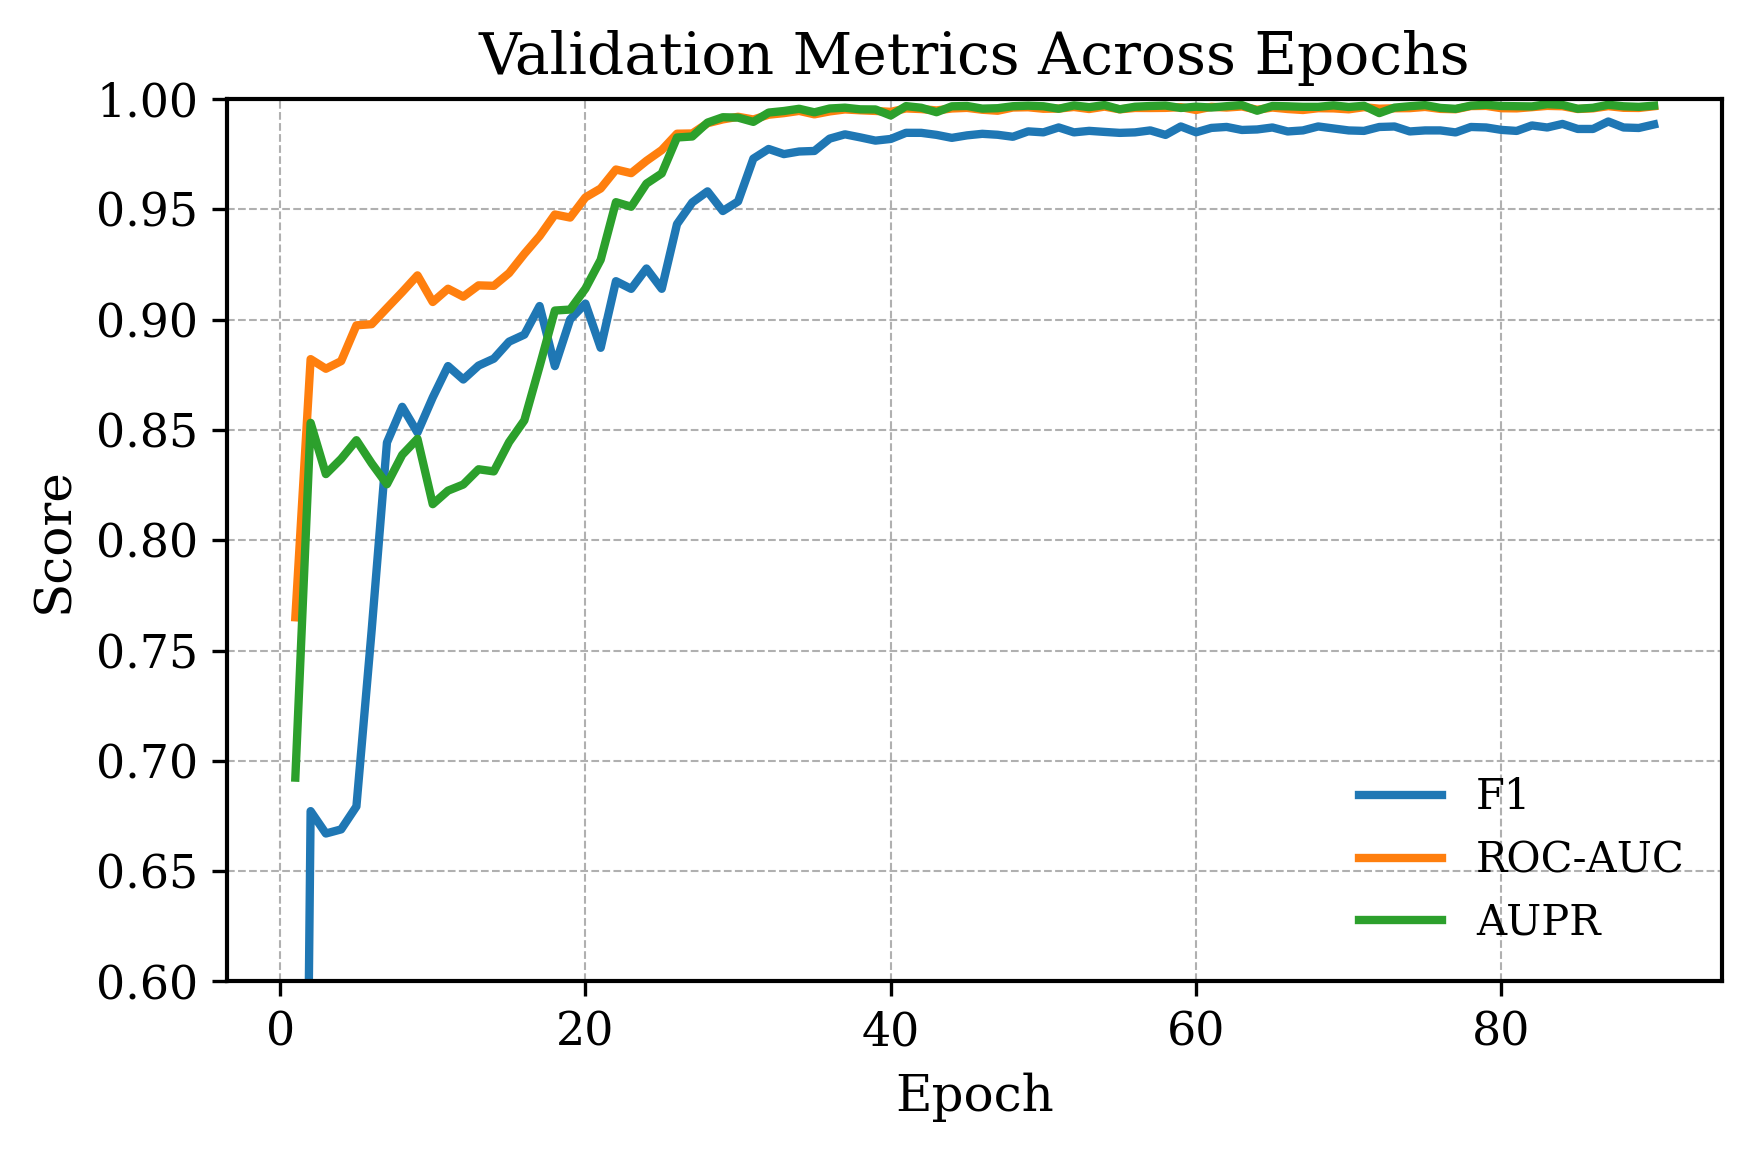

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Compute per-epoch mean & std across folds
# assume fold_results is a dict: fold_idx → {'val_f1s': [...], 'val_aucs': [...], 'val_auprs': [...]}
val_f1s  = np.stack([fold_results[k]['val_f1s']  for k in sorted(fold_results)])
val_aucs = np.stack([fold_results[k]['val_aucs'] for k in sorted(fold_results)])
val_auprs= np.stack([fold_results[k]['val_auprs'] for k in sorted(fold_results)])

mean_f1   = val_f1s.mean(axis=0)
std_f1    = val_f1s.std(axis=0)
mean_auc  = val_aucs.mean(axis=0)
std_auc   = val_aucs.std(axis=0)
mean_aupr = val_auprs.mean(axis=0)
std_aupr  = val_auprs.std(axis=0)

# Limit to first 90 epochs
max_epoch = 90
epochs    = np.arange(1, len(mean_f1) + 1)[:max_epoch]
mean_f1   = mean_f1[:max_epoch]
std_f1    = std_f1[:max_epoch]
mean_auc  = mean_auc[:max_epoch]
std_auc   = std_auc[:max_epoch]
mean_aupr = mean_aupr[:max_epoch]
std_aupr  = std_aupr[:max_epoch]

epochs = np.arange(1, len(mean_f1) + 1)

# 2. Journal-style settings
plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 12,
    "axes.linewidth": 1.0,
    "lines.linewidth": 2.0,
    "grid.linestyle": "--",
    "grid.linewidth": 0.5
})

# 3. Plot
fig, ax = plt.subplots(figsize=(6, 4))

# F1
ax.plot(epochs, mean_f1,   label="F1")
# ROC-AUC
ax.plot(epochs, mean_auc,  label="ROC-AUC")
# AUPR
ax.plot(epochs, mean_aupr, label="AUPR")

# 4. Labels, grid, legend
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("Validation Metrics Across Epochs")
ax.grid(True)
ax.legend(loc="lower right", frameon=False)
ax.set_ylim(0.6, 1)

# 5. Save
plt.tight_layout()
plt.savefig("figure_val_all_metrics.svg", format="svg")
plt.savefig("figure_val_all_metrics.png", format="png")
plt.show()


In [21]:
#Create mapping from name → integer index for each node type
drug2idx    = {name: i for i, name in enumerate(drugs)}
disease2idx = {name: i for i, name in enumerate(diseases)}
prot2idx    = {name: i for i, name in enumerate(proteins)}
# Read node embeddings saved as a torch file
# Assumes embeddings are saved as a tensor with shape (num_nodes, embedding_dim)
# and that the order matches the concatenation of [drugs, diseases, proteins]
import torch
import pandas as pd

# Set the path to the saved embeddings file (update as needed)
emb_path = "node_embeddings_200_epoch.pt"
embeddings = torch.load(emb_path)  # shape: (num_nodes, embedding_dim)

# Get counts for slicing
num_drugs = len(drug2idx)
num_diseases = len(disease2idx)
num_proteins = len(prot2idx)

# Sanity check
assert embeddings.shape[0] == num_drugs + num_diseases + num_proteins, \
    "Embedding count does not match total number of nodes."

# Invert mapping dicts for index → name
idx2drug = {v: k for k, v in drug2idx.items()}
idx2disease = {v: k for k, v in disease2idx.items()}

# Slice embeddings
drug_emb = embeddings[:num_drugs]
disease_emb = embeddings[num_drugs:num_drugs+num_diseases]

# Create DataFrames
drug_df = pd.DataFrame(drug_emb.cpu().numpy())
drug_df.insert(0, "DrugID", [idx2drug[i] for i in range(num_drugs)])

disease_df = pd.DataFrame(disease_emb.cpu().numpy())
disease_df.insert(0, "DiseaseID", [idx2disease[i] for i in range(num_diseases)])

# Save to CSV
drug_df.to_csv("drug_embeddings_plot.csv", index=False)
disease_df.to_csv("disease_embeddings_plot.csv", index=False)

print("Saved embeddings to CSV files.")

# drug_df: columns = ["DrugID", emb_0, emb_1, ...]
# disease_df: columns = ["DiseaseID", emb_0, emb_1, ...]


Saved embeddings to CSV files.


In [25]:
drug_df

,DrugID,0,1,2,3,4,5,6,7,8,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
0,DB06789,-0.352018,-0.204982,0.138788,0.945023,0.237166,-0.308163,-0.173360,-0.678275,-1.073541,...,-0.619533,0.253733,-0.218119,0.471856,-0.256615,0.116625,-0.230658,0.159099,0.479561,0.022369
1,DB01104,-1.451959,-0.648394,-0.340698,0.969143,1.555861,-1.580959,-0.407380,0.615842,-0.306452,...,-1.994487,-0.686208,1.062561,-0.267312,-1.176479,-0.017694,1.038445,1.247799,1.099291,-0.110509
2,DB03175,0.027740,0.382925,0.358275,-0.045833,-0.163579,0.122245,-0.264075,0.417996,-0.282713,...,-0.076384,-0.576065,0.706853,0.104896,-0.049076,-0.347868,0.468838,-0.218565,-0.398176,-0.421781
3,DB11842,-0.736626,-0.318041,0.228557,1.256617,0.438488,-0.631520,-0.688256,-0.414604,-1.040674,...,-1.284623,0.333082,-0.104594,0.517707,-0.722937,-0.082402,-0.250520,0.175002,0.485037,-0.240787
4,DB01442,-0.519701,0.108961,0.674222,1.108328,0.119257,-0.178436,-0.793634,0.001400,-0.982114,...,-1.137104,0.027328,0.203558,0.913630,-0.882750,-0.346467,-0.247328,-0.379150,-0.018675,-0.582307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2280,DB15090,0.178433,0.168854,0.482550,0.575640,-0.439620,0.349930,-0.351801,-0.488535,-0.884984,...,-0.017027,0.315995,-0.270052,0.670357,0.070007,-0.150117,-0.470409,-0.492654,-0.198736,-0.194285
2281,DB15270,0.098669,0.112358,0.482158,0.685549,-0.384199,0.299931,-0.395920,-0.541286,-0.969268,...,-0.121974,0.390557,-0.324515,0.727498,0.000178,-0.129786,-0.535764,-0.465353,-0.138525,-0.186814
2282,DB15283,0.097643,0.144490,0.462908,0.599741,-0.360296,0.274892,-0.380638,-0.433481,-0.860675,...,-0.120762,0.273958,-0.205413,0.657967,0.004325,-0.163892,-0.400509,-0.456424,-0.162673,-0.207318
2283,DB14851,0.097562,0.122592,0.477960,0.662081,-0.377707,0.292474,-0.393305,-0.509415,-0.939549,...,-0.123357,0.355526,-0.287553,0.708644,0.000669,-0.140851,-0.495206,-0.463335,-0.146333,-0.194184


In [26]:
import pandas as pd
import numpy as np

# ─── CONFIG ───────────────────────────────────────────────────────────────────

DISEASE_CSV = "disease_embeddings_plot.csv"
DRUG_CSV = "drug_embeddings_plot.csv"

# Column names in each CSV:
DISEASE_ID_COL = "DiseaseID"      # adjust if different
DRUG_ID_COL    = "DrugID"       # adjust if different

# Which nodes do you want to label/highlight?
# Use the exact IDs as they appear in your CSVs.

# #drug and Disease mapping dict
# disease_name_dict = {
#                 'D000544' : 'Alzheimer Disease',
#                 'D015140' : 'Vascular Dementia',
#                 'D010300' : 'Parkinson Disease Dementia',
#                 'D057180' : 'Frontotemporal Dementia',
#                 'D006816' : 'Huntington Disease',
#                 'D006850' : 'Normal Pressure Hydrocephalus',
#                 'D020961' : 'Lewy Body Disease'
#                     }

# FDA_approved_AD_drugs = {
#                 'DB12274' : 'Aducanumab',
#                 'DB00843' : 'Donepezil',
#                 'DB00674' : 'Galantamine',
#                 'DB00989' : 'Rivastigmine',
#                 'DB01043' : 'Memantine',
#                 'DB09128' : 'Brexpiprazole'
#                         }
TO_LABEL = {
    'D000544','D015140','D010300','D057180','D006816','D006850','D020961',
    'DB12274','DB00843','DB00674','DB00989','DB01043','DB09128'
}
# ──────────────────────────────────────────────────────────────────────────────

# 1) Load embeddings + IDs for diseases
df_dis = pd.read_csv(DISEASE_CSV)
dis_ids  = df_dis[DISEASE_ID_COL].astype(str).tolist()
# assume the rest of the columns are your embedding dims
dis_embs = df_dis.drop(columns=[DISEASE_ID_COL]).values

# 2) Load embeddings + IDs for drugs
df_drug = pd.read_csv(DRUG_CSV)
drug_ids  = df_drug[DRUG_ID_COL].astype(str).tolist()
drug_embs = df_drug.drop(columns=[DRUG_ID_COL]).values

# 3) Stack embeddings & build metadata
emb_matrix = np.vstack([dis_embs, drug_embs])
all_ids     = dis_ids + drug_ids
all_types   = ["disease"] * len(dis_ids) + ["drug"] * len(drug_ids)

meta = pd.DataFrame({
    "node_id":   all_ids,
    "node_type": all_types
})

# 4) Add 'label' column: only show text for IDs in TO_LABEL
meta["label"] = meta["node_id"].where(meta["node_id"].isin(TO_LABEL), "")

# 5) Add 'highlight' column: two classes for coloring
meta["highlight"] = np.where(
    meta["node_id"].isin(TO_LABEL),
    "★ highlighted",
    "normal"
)

# Reorder metadata so 'label' is first (Projector uses first column for hover/labels)
meta = meta[["label", "node_id", "node_type", "highlight"]]

# 6) Write embeddings.tsv
with open("embeddings.tsv", "w") as f_emb:
    for vec in emb_matrix:
        f_emb.write("\t".join(f"{v:.6f}" for v in vec) + "\n")

# 7) Write metadata.tsv
meta.to_csv("metadata.tsv", sep="\t", index=False)

print(f"Wrote embeddings.tsv ({emb_matrix.shape[0]}×{emb_matrix.shape[1]})")
print(f"Wrote metadata.tsv ({len(meta)} rows, {len(meta.columns)} columns)")


Wrote embeddings.tsv (3197×1024)
Wrote metadata.tsv (3197 rows, 4 columns)
